# Dimensionality Reduction Case Study — Digits Dataset

**Dataset:** handwritten digit images (8x8 pixels each), flattened into 64 numeric features, 1,797 samples, 10 digit classes (0-9).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')         

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Loading the Data

Each image is an 8x8 grid of pixel intensities (0-16). Flattened, that's 64 numeric features per sample — genuinely high-dimensional, and a good one to visualize since we can look at the actual image behind any data point.


Digits dataset shape: (1797, 64)


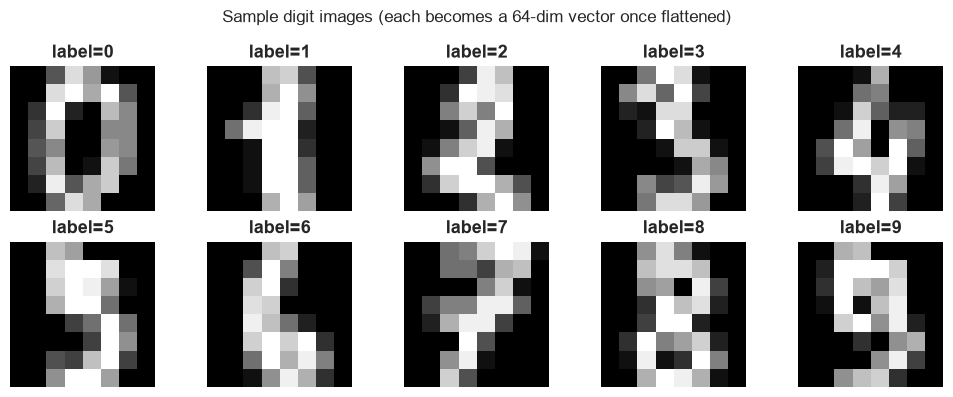

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()          # loads 1797 handwritten digit images, built into sklearn
X_dig = digits.data             # flattened pixel data: shape (1797, 64) one row per image
y_dig = digits.target           # the true digit (0-9) for each image, used only for evaluation later
print('Digits dataset shape:', X_dig.shape)   # 1797 images x 64 pixel features

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')   # the 8x8 image, before it gets flattened to 64 features
    ax.set_title(f'label={digits.target[i]}'); ax.axis('off')
plt.suptitle('Sample digit images (each becomes a 64-dim vector once flattened)')
plt.tight_layout(); plt.show()


## 2. Preprocessing

Pixel intensities all share the same 0-16 range already, unlike datasets that mix very different units. We check whether `StandardScaler` still changes anything meaningful before committing to it.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_dig_raw = X_dig                                        # unscaled: raw 0-16 pixel intensities
X_dig_scaled = StandardScaler().fit_transform(X_dig)      # scaled: every pixel position mean 0, std 1

# fit the SAME k=10 K-Means on both versions and compare silhouette, to see if scaling matters here
for name, data in [('Raw (0-16 pixel values)', X_dig_raw), ('StandardScaler', X_dig_scaled)]:
    km_check = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit(data)
    sil = silhouette_score(data, km_check.labels_)
    print(f'{name:25s} silhouette = {sil:.3f}')

Raw (0-16 pixel values)   silhouette = 0.182
StandardScaler            silhouette = 0.139


## 3. PCA
Linear method

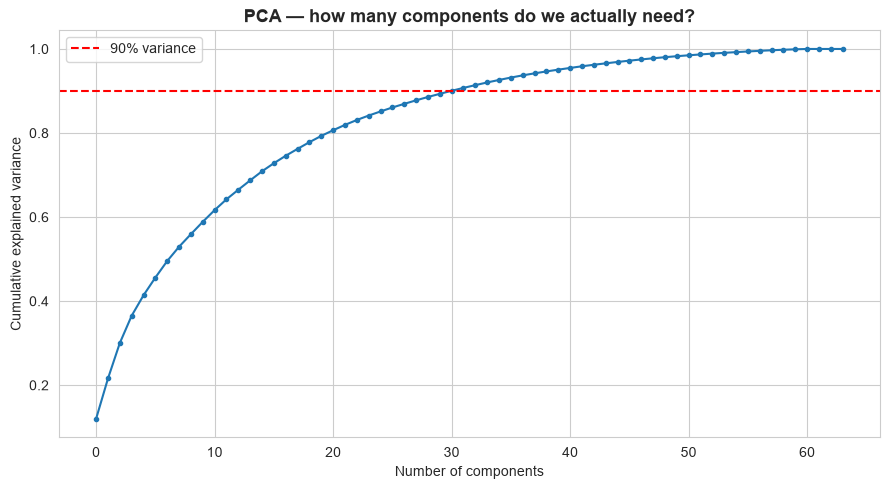

Components needed for 90% variance: 31 (down from 64 raw pixel features)


In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_dig_scaled)                        # fit PCA keeping ALL 64 components, just to inspect variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)   # running total of variance captured as we add components

plt.figure()
plt.plot(cum_var, marker='.')
plt.axhline(0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA — how many components do we actually need?')
plt.legend(); plt.tight_layout(); plt.show()

n_90 = np.argmax(cum_var >= 0.90) + 1   # first index where we cross 90% variance (+1 since components start at 1, not 0)
print(f'Components needed for 90% variance: {n_90} (down from 64 raw pixel features)')


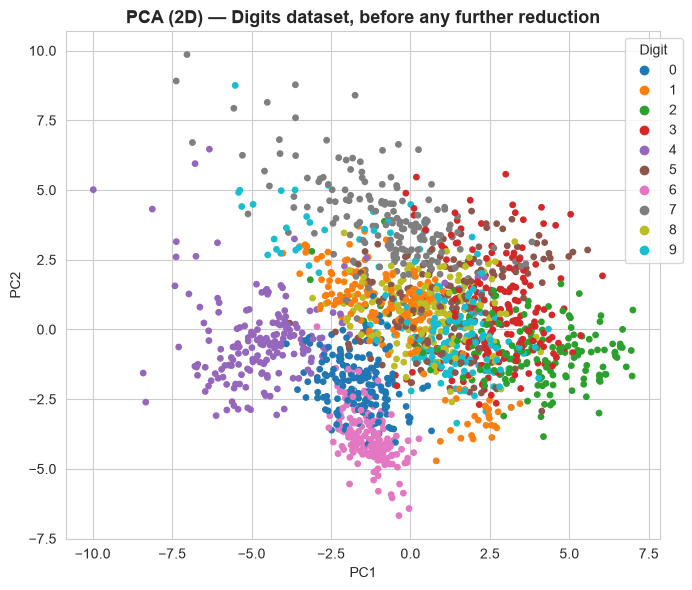

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)   # this time keep only 2 components, for plotting
X_pca_dig = pca_2d.fit_transform(X_dig_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_pca_dig[:, 0], X_pca_dig[:, 1], c=y_dig, cmap='tab10', s=15)  # color by TRUE digit label
plt.legend(*sc.legend_elements(), title='Digit', bbox_to_anchor=(1.05, 1))
plt.title('PCA (2D) — Digits dataset, before any further reduction')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()


## 4. Kernel PCA

Applies a kernel trick (here, RBF) before projecting, capturing some nonlinear relationships plain PCA misses. We tune `gamma` by checking which value gives the best silhouette separation.


gamma= 0.01  ->  silhouette = 0.389
gamma= 0.02  ->  silhouette = 0.409
gamma= 0.03  ->  silhouette = 0.400
gamma= 0.05  ->  silhouette = 0.414
gamma=  0.1  ->  silhouette = 0.747
Best gamma: 0.1


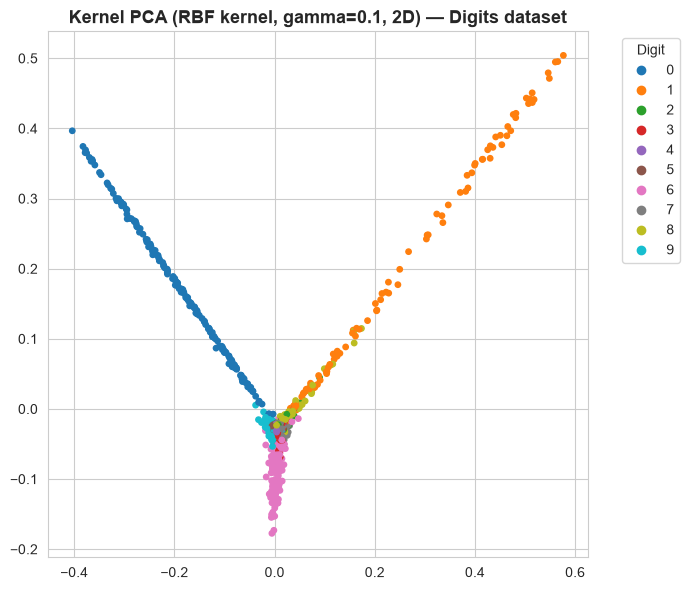

In [ ]:
from sklearn.decomposition import KernelPCA

best_gamma, best_sil = None, -1
for gamma in [0.01, 0.02, 0.03, 0.05, 0.1]:                # scan a range of gamma values (RBF kernel width)
    kpca_check = KernelPCA(n_components=2, kernel='rbf', gamma=gamma, random_state=RANDOM_STATE)
    emb_check = kpca_check.fit_transform(X_dig_scaled)      # project to 2D with this gamma
    # score how well a quick K-Means (k=10) separates this particular 2D embedding
    sil = silhouette_score(emb_check, KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit_predict(emb_check))
    print(f'gamma={gamma:5}  ->  silhouette = {sil:.3f}')
    if sil > best_sil:
        best_sil, best_gamma = sil, gamma               # keep track of the best-scoring gamma so far

# refit Kernel PCA one more time using whichever gamma scored best above
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=best_gamma, random_state=RANDOM_STATE)
X_kpca_dig = kpca.fit_transform(X_dig_scaled)
print('Best gamma:', best_gamma)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_kpca_dig[:, 0], X_kpca_dig[:, 1], c=y_dig, cmap='tab10', s=15)
plt.legend(*sc.legend_elements(), title='Digit', bbox_to_anchor=(1.05, 1))
plt.title(f'Kernel PCA (RBF kernel, gamma={best_gamma}, 2D) — Digits dataset')
plt.tight_layout(); plt.show()


## 5. t-SNE


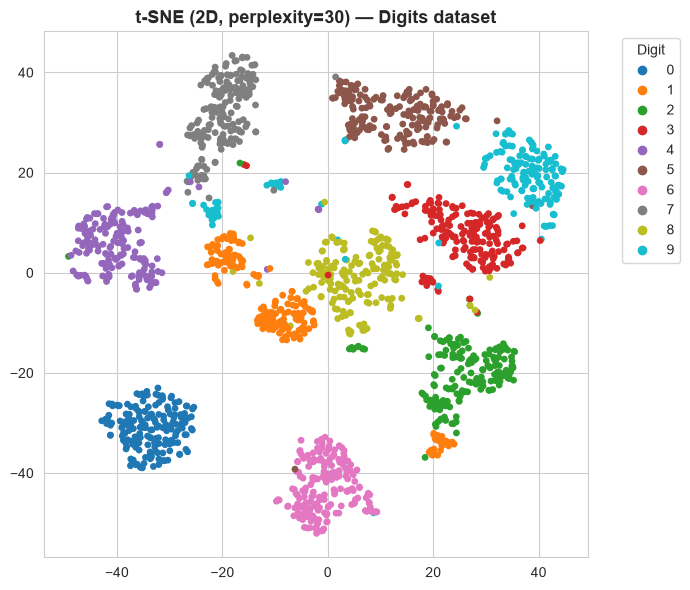

In [ ]:
from sklearn.manifold import TSNE

# perplexity roughly controls how many neighbors each point considers - 30 is a solid default
# for a dataset this size (too small -> overly local/noisy, too large -> loses local detail)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne_dig = tsne.fit_transform(X_dig_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_tsne_dig[:, 0], X_tsne_dig[:, 1], c=y_dig, cmap='tab10', s=15)
plt.legend(*sc.legend_elements(), title='Digit', bbox_to_anchor=(1.05, 1))
plt.title('t-SNE (2D, perplexity=30) — Digits dataset')
plt.tight_layout(); plt.show()


## 6. UMAP

Also nonlinear and neighborhood-based like t-SNE, but generally keeps more global structure and runs faster, and can transform new/unseen points once fitted.


In [ ]:
import umap

# n_neighbors controls the local-vs-global tradeoff (like t-SNE's perplexity);
# min_dist controls how tightly points are allowed to pack together in the embedding
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_umap_dig = reducer.fit_transform(X_dig_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_umap_dig[:, 0], X_umap_dig[:, 1], c=y_dig, cmap='tab10', s=15)
plt.legend(*sc.legend_elements(), title='Digit', bbox_to_anchor=(1.05, 1))
plt.title('UMAP (2D, n_neighbors=15) — Digits dataset')
plt.tight_layout(); plt.show()


ModuleNotFoundError: No module named 'umap'

## 7. Comparing All Four Methods Side by Side


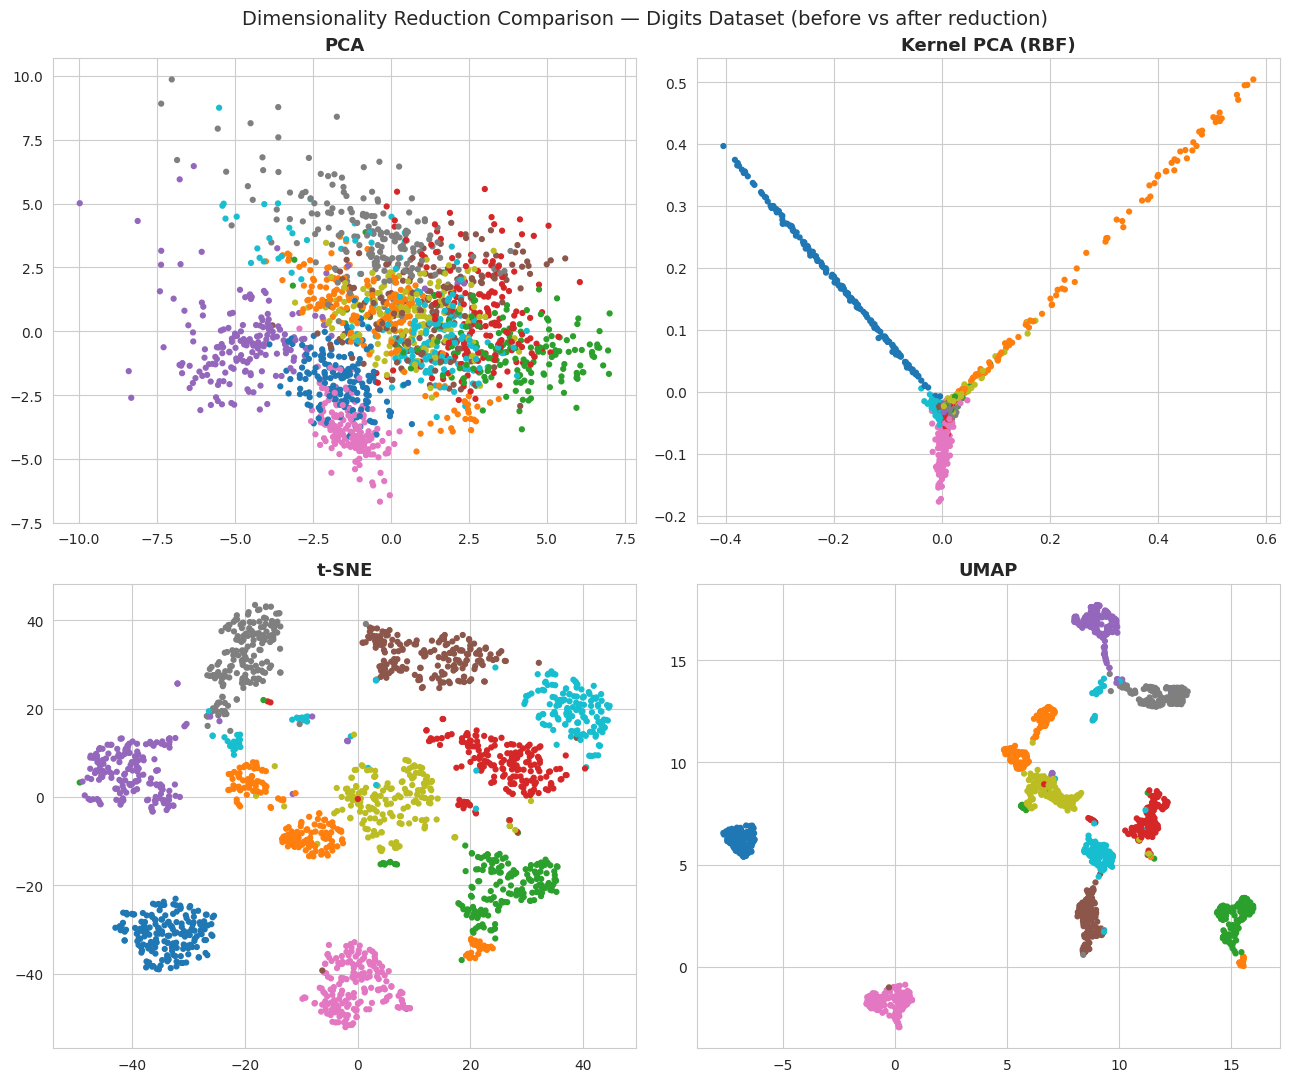

In [ ]:
# put all 4 embeddings side by side, each colored by the TRUE digit label, for a quick visual comparison
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, emb) in zip(axes.ravel(),
                            [('PCA', X_pca_dig), ('Kernel PCA (RBF)', X_kpca_dig),
                             ('t-SNE', X_tsne_dig), ('UMAP', X_umap_dig)]):
    ax.scatter(emb[:, 0], emb[:, 1], c=y_dig, cmap='tab10', s=12)
    ax.set_title(name)
plt.suptitle('Dimensionality Reduction Comparison — Digits Dataset (before vs after reduction)', fontsize=14)
plt.tight_layout(); plt.show()


In [ ]:
# Quantify each embedding: run K-Means (k=10) on it and see how well that recovers the true digit groups
dimred_results = {}
for name, emb in [('PCA', X_pca_dig), ('Kernel PCA', X_kpca_dig), ('t-SNE', X_tsne_dig), ('UMAP', X_umap_dig)]:
    km_emb = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit(emb)   # cluster the 2D embedding itself
    dimred_results[name] = dict(
        Silhouette=silhouette_score(emb, km_emb.labels_),                # how separated the clusters look, alone
        ARI_vs_true_digits=adjusted_rand_score(y_dig, km_emb.labels_)    # how well those clusters match real digits
    )

dimred_df = pd.DataFrame(dimred_results).T.round(3)
dimred_df


,Silhouette,ARI_vs_true_digits
PCA,0.378,0.326
Kernel PCA,0.747,0.054
t-SNE,0.574,0.781
UMAP,0.705,0.871


### Why does one method perform better here?

**PCA** is linear, so it can only "unfold" the digit manifold so far — digits with visually similar strokes (like 4/9, or 3/8) still overlap heavily in the 2D projection.

**Kernel PCA (RBF)** helps a little with nonlinearity, but it's still a global variance-based method, and the right `gamma` is finicky to pick.

**t-SNE and UMAP** both clearly separate almost all 10 digit classes into distinct, well-formed groups, because they explicitly optimize for preserving *local neighborhoods* — which matches how digit shapes actually cluster (similar strokes stay close together). This shows up in both the visual separation and the quantitative Silhouette/ARI numbers above.

**Takeaway:** UMAP (with t-SNE close behind) wins on Digits because the true class structure is nonlinear and manifold-shaped, which linear PCA fundamentally can't capture as well. Unlike a text/TF-IDF dataset where a lot of the signal can be linear, image data like this genuinely needs a nonlinear method to separate all 10 classes cleanly.
